#### Import Libraries

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score

#### Import Datasets

In [25]:
%store -r X_cluster_Scaled
%store -r X_x
%store -r y

X = X_x[["Type", "Rotational speed [rpm]", "Torque [Nm]", "Air temperature [K]", "Process temperature [K]", "Tool wear [min]"]]
X = pd.DataFrame(X) 

In [26]:
X_x.reset_index(drop=True, inplace=True)
y.reset_index(drop=True, inplace=True)

combined_df = pd.concat([X_x, y], axis=1)

print(combined_df.head())

   Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0     2                298.1                    308.6                    1551   
1     1                298.2                    308.7                    1408   
2     1                298.1                    308.5                    1498   
3     1                298.2                    308.6                    1433   
4     1                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  KMeans_Cluster  Failure Type  
0         42.8                0               1             1  
1         46.3                3               1             1  
2         49.4                5               1             1  
3         39.5                7               1             1  
4         40.0                9               1             1  


#### K-Mean CLustering

##### K-Elbow method

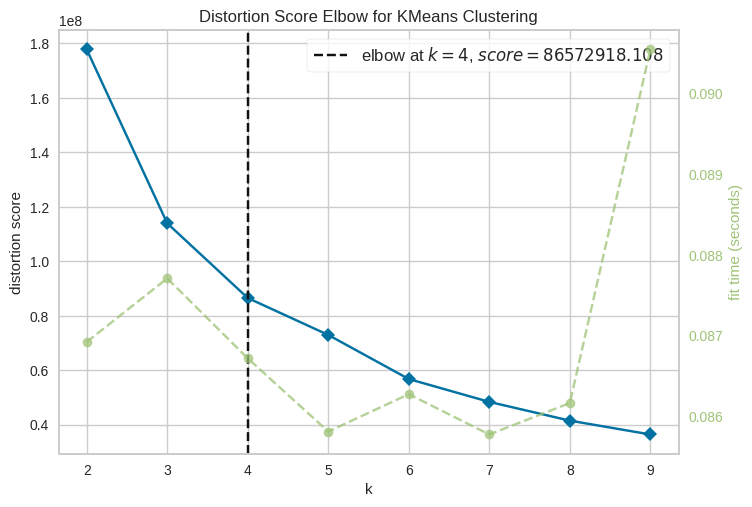

<AxesSubplot: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [27]:
kmeans_model = KMeans()

visualizer = KElbowVisualizer(kmeans_model, k=(2,10)) 
visualizer.fit(X)
visualizer.show()

In [28]:
kmeans_model = KMeans(init='random', n_clusters=4, n_init=10, max_iter=300, random_state=42)

X['KMeans_Cluster'] = kmeans_model.fit_predict(X.drop(columns=['KMeans_Cluster'], errors='ignore'))

cluster_counts = X['KMeans_Cluster'].value_counts()
print(cluster_counts)

KMeans_Cluster
3    4409
2    3961
1    1416
0     196
Name: count, dtype: int64


In [29]:
if len(X_x) == len(y):
    X_x['KMeans_Cluster'] = kmeans_model.fit_predict(X_x)

    combined_df = pd.concat([X_x, y.reset_index(drop=True)], axis=1)

    cluster_distribution = combined_df.groupby(['Failure Type', 'KMeans_Cluster']).size().reset_index(name='Count')

    print(cluster_distribution)
else:
    print(f"Mismatch in lengths: X_test_Scaled has {len(X_x)} rows, but y_test has {len(y)} rows.")


    Failure Type  KMeans_Cluster  Count
0              0               3    112
1              1               0    163
2              1               1   1409
3              1               2   3941
4              1               3   4139
5              2               2      2
6              2               3     76
7              3               0     31
8              3               3     64
9              4               0      2
10             4               1      7
11             4               2     18
12             4               3     18


#### Silhouette Coefficient

In [30]:
silhouette_kmeans = silhouette_score(X.drop(columns=['KMeans_Cluster']), X['KMeans_Cluster'])
print(f'Silhouette Coefficient: {silhouette_kmeans}')

Silhouette Coefficient: 0.3731494640460261


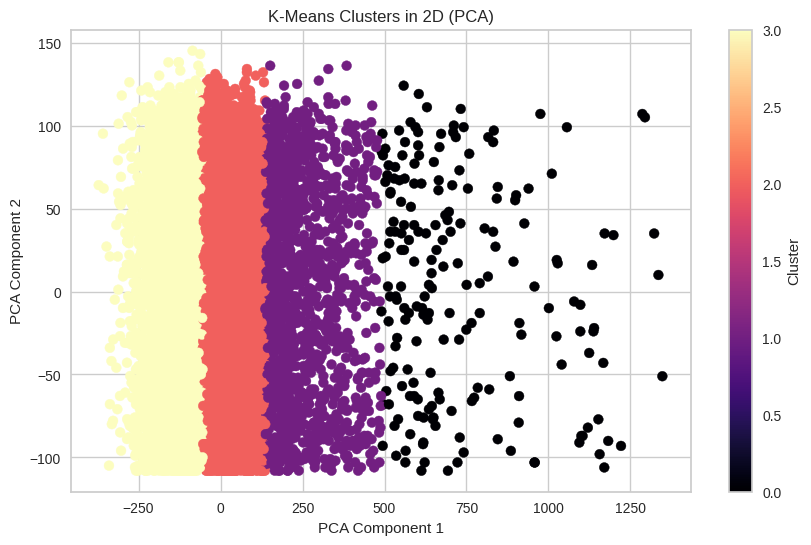

In [31]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.drop(columns=['KMeans_Cluster']))

X_pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
X_pca_df['KMeans_Cluster'] = X['KMeans_Cluster']

# Plot PCA results
plt.figure(figsize=(10, 6))
plt.scatter(X_pca_df['PCA1'], X_pca_df['PCA2'], c=X_pca_df['KMeans_Cluster'], cmap='magma', s=50)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clusters in 2D (PCA)')
plt.colorbar(label='Cluster')
plt.show()

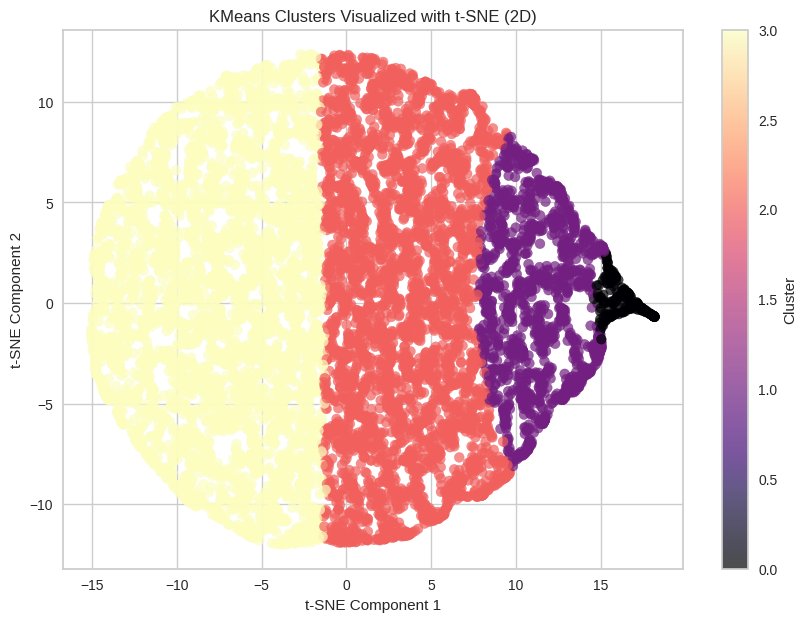

In [32]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=42)
X_tsne = tsne.fit_transform(X.drop(columns=['KMeans_Cluster'], errors='ignore'))

plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=X['KMeans_Cluster'], cmap='magma', s=50, alpha=0.7)
plt.colorbar(label='Cluster')
plt.title("KMeans Clusters Visualized with t-SNE (2D)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

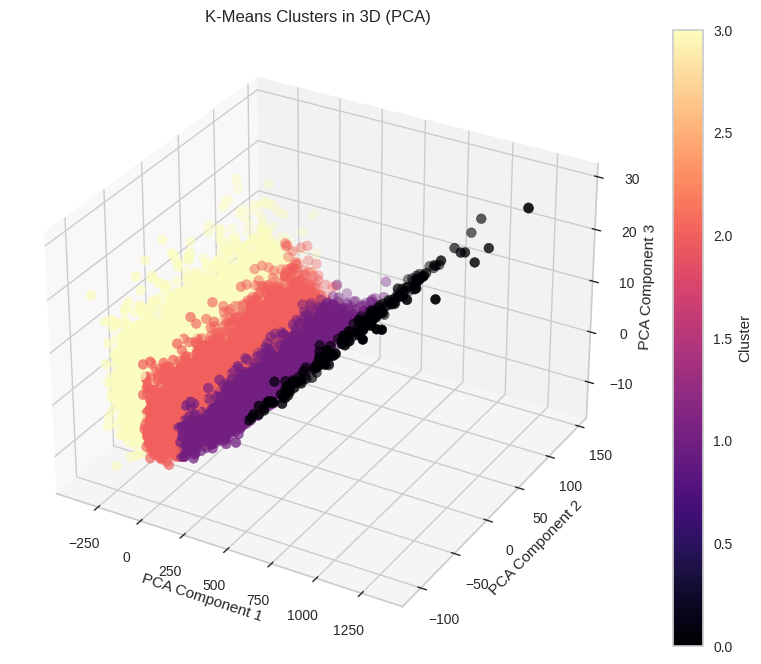

In [33]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X.drop(columns=['KMeans_Cluster']))

X_pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2', 'PCA3'])
X_pca_df['KMeans_Cluster'] = X['KMeans_Cluster']

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_df['PCA1'], X_pca_df['PCA2'], X_pca_df['PCA3'],
                     c=X_pca_df['KMeans_Cluster'], cmap='magma', s=50)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('K-Means Clusters in 3D (PCA)')
fig.colorbar(scatter, label='Cluster')
plt.show()

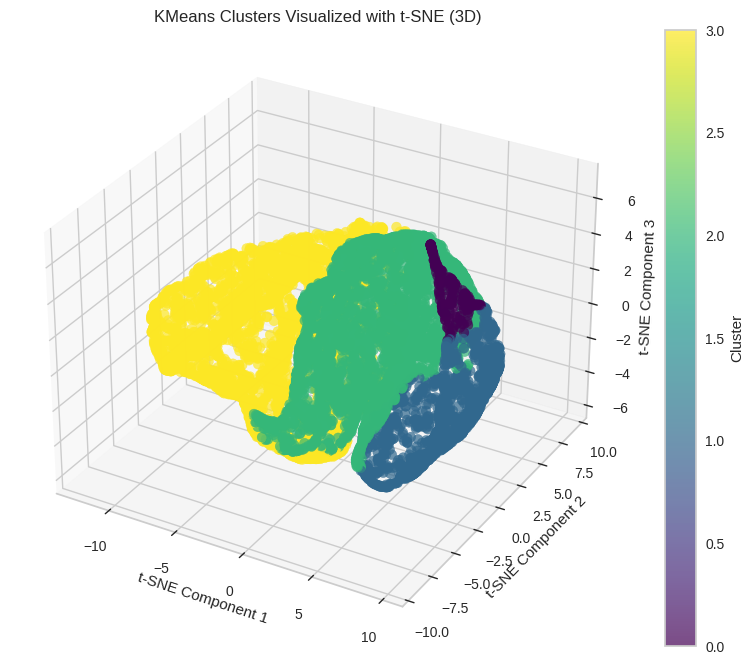

In [34]:
tsne = TSNE(n_components=3, perplexity=30, n_iter=300, random_state=42)
X_tsne_3d = tsne.fit_transform(X.drop(columns=['KMeans_Cluster'], errors='ignore'))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2], c=X['KMeans_Cluster'], cmap='viridis', s=50, alpha=0.7)

ax.set_title("KMeans Clusters Visualized with t-SNE (3D)")
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_zlabel("t-SNE Component 3")
fig.colorbar(scatter, label='Cluster')
plt.show()

<Figure size 1000x800 with 0 Axes>

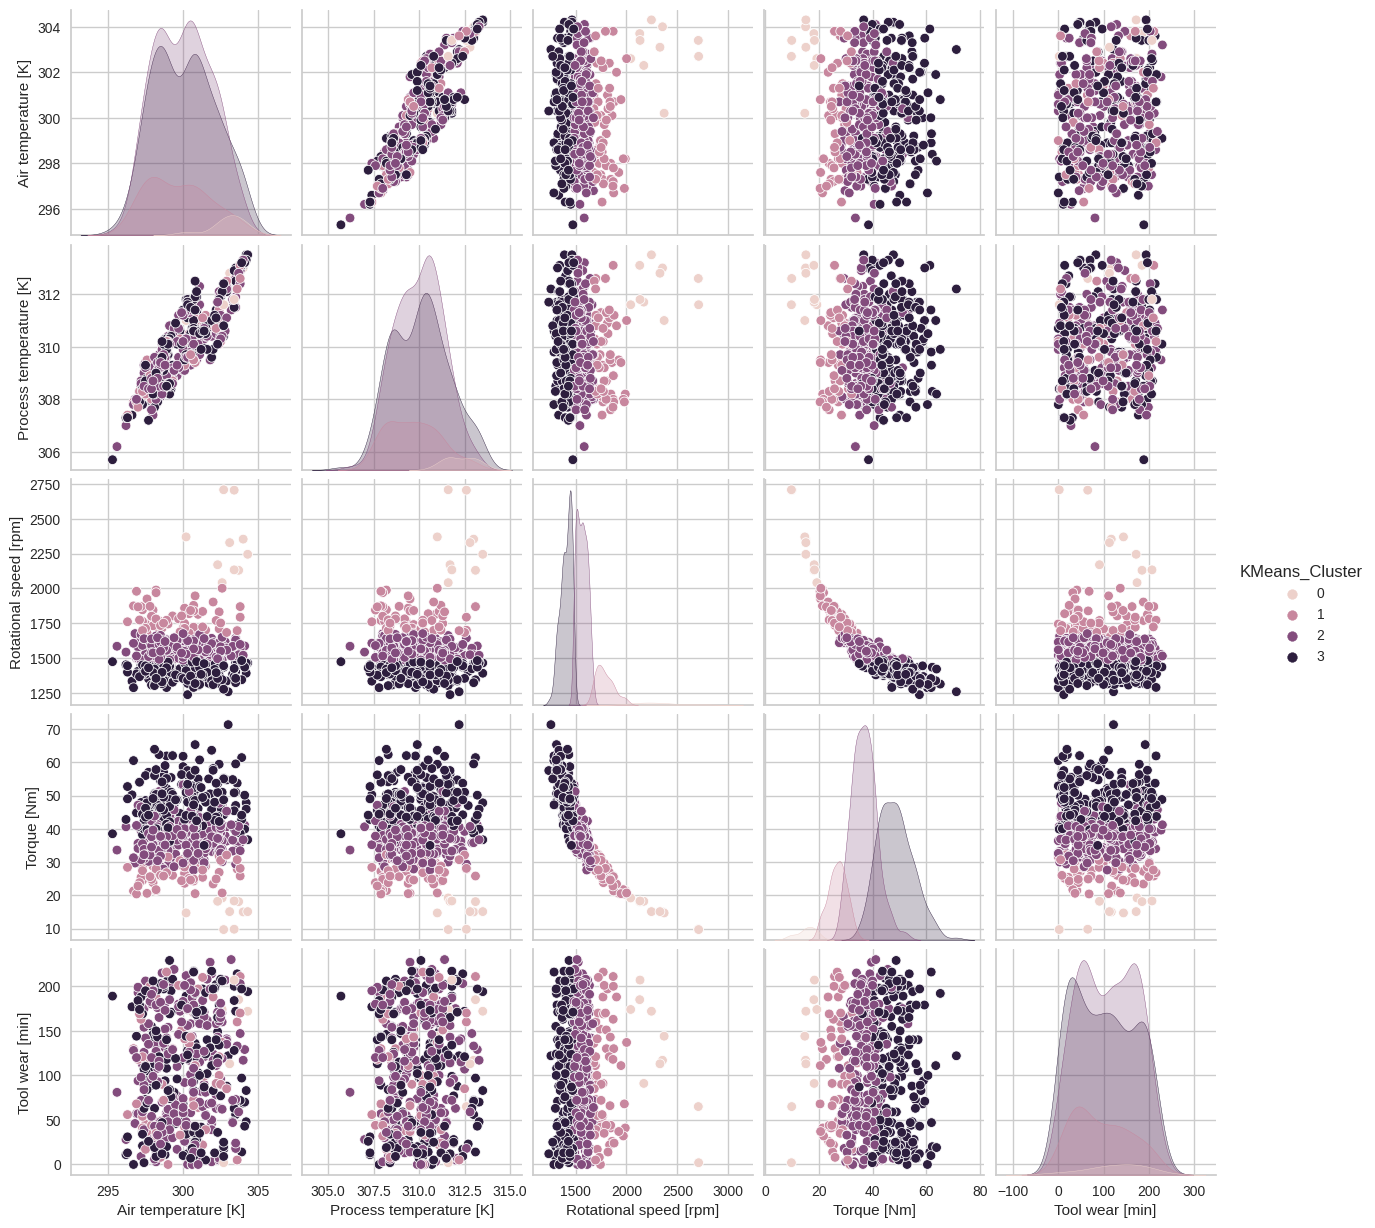

In [35]:
plt.figure(figsize=(10, 8))

sns.pairplot(X.sample(frac=0.05), hue="KMeans_Cluster", vars=["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"])
plt.show()